# 2교시 · 환경 · 4bit 로드 · 베이스라인

> **VLM 경량화 2일 과정 · Day 1 (2교시) · 실습**
> 실습 환경: **Google Colab (T4 GPU)** · 모델: **Qwen/Qwen3-VL-4B-Instruct** · 데이터: **HuggingFaceM4/ChartQA**

---

## 이 교시의 목표
- Colab **T4 런타임을 고정**하고, 의존성을 **재현 가능하게** 설치한다.
- `BitsAndBytesConfig`(nf4·이중양자화·compute_dtype=fp16)로 **Qwen3-VL-4B를 4bit로 로드**하고 **VRAM을 측정**한다.
- 파인튜닝 **전** ChartQA 추론을 관찰해, 4교시 학습이 무엇을 바꾸는지 **기준점(baseline)** 을 잡는다.

> 1교시 복습: *가중치 메모리 ≈ 파라미터 수 × (비트/8)*. 4B를 4bit로 올리면 약 2GB — T4(16GB)에 학습 여유까지 생깁니다. 이번 교시는 그걸 **실제로** 확인합니다.


## 0. 공통 헤더 — Google Drive(VLM_FT_2) 마운트 + HF_TOKEN 로드

> 📌 **모든 Day 1 노트북은 이 셀을 먼저 실행합니다.** Google Drive의 작업 폴더 **`VLM_FT_2`** 를 마운트하고, `.env`의 **HF_TOKEN**을 불러옵니다.
> - `VLM_DIR` / `DATA_DIR` : 교시 간 공유 폴더(전처리 데이터·어댑터·결과가 여기 모입니다).
> - **HF_TOKEN**: `VLM_FT_2/.env` 에 `HF_TOKEN=hf_...` 한 줄을 넣어두면 자동 로드됩니다(다운로드 경고 방지·비공개 모델 접근). `login()`은 호출하지 않습니다(환경변수만으로 충분, 경고 방지).

In [3]:
# ════════════════════════════════════════════════════════════
#  공통 헤더 · Google Drive(VLM_FT_2) 마운트 + HF_TOKEN(.env) 로드
#  (모든 Day1 노트북 상단에서 동일하게 실행)
# ════════════════════════════════════════════════════════════
import os

# (1) Google Drive 마운트 → 작업 폴더 VLM_FT_2 (교시 간 데이터·어댑터·결과 공유)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    VLM_DIR = '/content/drive/MyDrive/VLM_FT_2'      # Drive 경로(권장)
except Exception:
    VLM_DIR = '/content/VLM_FT_2'                     # Colab 아니면 로컬 폴백
DATA_DIR = f'{VLM_DIR}/data'
os.makedirs(DATA_DIR, exist_ok=True)

# (2) .env 에서 HF_TOKEN 로드. login()은 부르지 않음(환경변수만으로 인증, 경고 없음).
try:
    from dotenv import load_dotenv
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'python-dotenv'])
    from dotenv import load_dotenv
ENV_PATH = f'{VLM_DIR}/.env'
if os.path.exists(ENV_PATH):
    load_dotenv(ENV_PATH)
    print('HF_TOKEN:', '로드됨' if os.environ.get('HF_TOKEN') else '없음')
else:
    print(f'.env 없음 — {ENV_PATH} 에 HF_TOKEN=hf_... 한 줄을 만들면 자동 로드됩니다(공개 데이터만 쓰면 없어도 됨)')
print('작업 폴더 VLM_DIR =', VLM_DIR)

Mounted at /content/drive
HF_TOKEN: 로드됨
작업 폴더 VLM_DIR = /content/drive/MyDrive/VLM_FT_2


## 0. 시작 전 — 런타임을 T4 GPU로 고정

Colab 상단 메뉴 **런타임 → 런타임 유형 변경 → 하드웨어 가속기: T4 GPU** 로 설정하세요.
아래 셀로 GPU가 잡혔는지 먼저 확인합니다.

In [4]:
# ── GPU 확인 ────────────────────────────────────────────────
# nvidia-smi: 현재 할당된 GPU와 메모리를 출력. 'Tesla T4'가 보이면 정상.
!nvidia-smi --query-gpu=name,memory.total,memory.used --format=csv

name, memory.total [MiB], memory.used [MiB]
Tesla T4, 15360 MiB, 0 MiB


**결과 읽기 — GPU 확인**

`Tesla T4, 15360 MiB, ...` 가 보이면 T4가 정상 할당된 것입니다. 총 VRAM은 약 **15 GB**(15360 MiB)로, 1교시에서 가정한 16 GB와 사실상 같습니다. `memory.used` 열은 *그 시점의 점유량*으로, 드라이버·CUDA 컨텍스트나 앞서 실행한 셀의 잔여가 잡혀 있을 수 있습니다 — 그래서 실제 가용 여유는 총량보다 조금 적습니다.

## 1. 의존성 설치

Qwen3-VL은 비교적 최신 모델이라 **transformers 4.57 이상**이 필요합니다(아키텍처 `qwen3_vl` 지원). 4bit 로드는 **bitsandbytes**가 담당합니다.

| 패키지 | 역할 |
|---|---|
| `transformers` | 모델·프로세서 로드, 채팅 템플릿 |
| `bitsandbytes` | **4bit(NF4) 양자화 로드** |
| `accelerate` | device 배치·메모리 관리 |
| `datasets` | ChartQA 로드 |

> ⚠️ 설치 후 **transformers가 너무 낮으면** `Qwen3VLForConditionalGeneration`을 못 찾습니다. 아래 셀이 버전을 검증합니다. 설치 직후 Colab이 재시작을 권하면 **런타임 재시작 후 이 셀부터 다시 실행**하세요.

In [6]:
# ── 패키지 설치 ──────────────────────────────────────────────
# -q: 조용히,  -U: 최신으로 업그레이드.
# pillow<12 는 일부 이미지 처리 호환 이슈를 피하기 위한 안전 핀.
!pip install -q -U "transformers>=4.57" "accelerate>=1.0" "bitsandbytes>=0.44" "datasets>=3.0" "pillow<12"

# 설치된 버전 확인 + Qwen3-VL 지원 여부 검증
import transformers
print('transformers:', transformers.__version__)

# Qwen3-VL 전용 클래스가 임포트되는지 확인(안 되면 transformers가 낮은 것)
try:
    from transformers import Qwen3VLForConditionalGeneration 
    print('OK: Qwen3VLForConditionalGeneration 사용 가능')
except ImportError:
    raise RuntimeError('transformers가 너무 낮습니다. 위 셀로 업그레이드 후 런타임을 재시작하세요.')

transformers: 5.12.1
OK: Qwen3VLForConditionalGeneration 사용 가능


**결과 읽기 — 설치·버전 검증**

`transformers: 5.12.1` 처럼 **4.57 이상**이면 Qwen3-VL을 지원합니다. 이어 `Qwen3VLForConditionalGeneration` 임포트가 성공해 **'OK'** 가 출력됐습니다. 만약 이 검증이 `RuntimeError`로 떨어지면 transformers가 낮은 것이니, 위 설치 셀을 다시 돌리고 **런타임을 재시작**한 뒤 이 셀부터 실행하세요.

## 2. `BitsAndBytesConfig` — 4bit 로드 설정 이해하기

4bit 로드의 핵심은 이 설정 객체입니다. 필드별 의미:

| 필드 | 값 | 의미 |
|---|---|---|
| `load_in_4bit` | `True` | 가중치를 4bit로 로드 |
| `bnb_4bit_quant_type` | `"nf4"` | **NF4**(정규분포에 맞춘 4bit). 일반 int4보다 손실 적음 |
| `bnb_4bit_use_double_quant` | `True` | **이중 양자화**(scale도 양자화 → 추가 절약) |
| `bnb_4bit_compute_dtype` | `float16` | 실제 **연산은 fp16**으로(저장은 4bit). **T4는 bf16 미지원 → fp16** |

> 저장은 4bit로 작게, 연산 순간엔 fp16으로 복원해서 계산합니다. T4는 bf16을 지원하지 않으므로 **반드시 fp16**을 씁니다(A100이면 bf16).

In [7]:
# ── Qwen3-VL-4B 를 4bit 로 로드 ──────────────────────────────
import torch
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

MODEL_ID = 'Qwen/Qwen3-VL-4B-Instruct'   # 학습 대상 모델(4,437.8M 파라미터)

# 4bit 양자화 설정 (위 표의 내용을 그대로 코드로)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                      # 4bit 로드 on
    bnb_4bit_quant_type='nf4',              # NF4 사용
    bnb_4bit_use_double_quant=True,         # 이중 양자화 on
    bnb_4bit_compute_dtype=torch.float16,   # 연산 dtype = fp16 (T4)
)

# 프로세서: 이미지 전처리 + 채팅 템플릿 + 토크나이저를 하나로 묶은 객체
processor = AutoProcessor.from_pretrained(MODEL_ID)

# 모델 로드
#  - quantization_config: 위 4bit 설정 적용
#  - device_map='auto'  : 가능한 레이어를 GPU에 자동 배치
#  - dtype=torch.float16: 비양자화 부분(예: 일부 정규화)도 fp16
#  - attn_implementation='sdpa': T4에서 안정적인 어텐션 구현
# attention score  계산- sdpa :  Scaled Dot Product Attention 안정적이나 요즘에는 flash attention2 
model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    dtype=torch.float16,
    attn_implementation='sdpa',
)
model.eval()   # 추론 모드(드롭아웃 등 비활성화)
print('로드 완료:', MODEL_ID)

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/5.50k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

로드 완료: Qwen/Qwen3-VL-4B-Instruct


**결과 읽기 — 4bit 로드 + 경고에 대하여**

가중치 샤드를 내려받아 로드한 뒤 **'로드 완료'** 가 출력됩니다. 중간에 보이는

```
FutureWarning: _check_is_size will be removed in a future PyTorch release ...
```

는 **bitsandbytes/torch의 버전 예고용 경고**입니다. 동작에는 영향이 없으니 **무시해도 됩니다**(추론 셀에서도 한 번 더 보일 수 있습니다).

## 3. VRAM 측정 — 정말 4bit로 줄었나?

1교시에서 계산한 *4B 4bit ≈ 2GB* 가 실제로 맞는지 확인합니다. `torch.cuda`로 현재 점유 메모리를 읽습니다.

In [8]:
# ── 현재 GPU 메모리 사용량 측정 ──────────────────────────────
def gpu_mem_gb() -> dict:
    """현재 할당/예약된 GPU 메모리를 GB 단위로 반환."""
    # memory_allocated : 텐서가 실제 점유 중인 메모리
    # memory_reserved  : 캐싱 할당자가 예약해 둔 메모리(실사용 상한에 가까움)
    allocated = torch.cuda.memory_allocated() / (1024 ** 3)
    reserved  = torch.cuda.memory_reserved()  / (1024 ** 3)
    return {'allocated_GB': round(allocated, 2), 'reserved_GB': round(reserved, 2)}

print('모델 로드 후 VRAM:', gpu_mem_gb())
# 참고: 4B를 fp16(비양자화)로 올렸다면 가중치만 ~8.3GB. 4bit면 그 1/4 수준.

모델 로드 후 VRAM: {'allocated_GB': 2.71, 'reserved_GB': 2.76}


**결과 읽기 — 왜 ~2 GB가 아니라 2.88 GB?**

1교시 계산에선 4B를 4bit로 올리면 가중치가 **~2.07 GB**였는데, 실측은 `allocated_GB: 2.71` 로 더 큽니다. 차이는 **4bit로 양자화되지 *않은* 부분** 때문입니다.

- **비전 타워·프로젝터**(이미지 인코더)는 fp16으로 유지됩니다 — Day2에서 AWQ할 때 `ignore`하는 바로 그 부분입니다.
- **임베딩 · `lm_head` · 정규화층** 등도 보통 양자화 대상에서 빠집니다.
- bitsandbytes의 **연산 버퍼**와 CUDA 컨텍스트 상주분도 더해집니다.

즉 *LLM 선형층만 4bit(~2 GB)이고, 나머지(비전+임베딩+버퍼)가 더해져 ~2.71 GB* 가 됩니다. `reserved_GB: 2.76` 은 PyTorch 캐싱 할당자가 미리 잡아둔 양으로 **실사용 상한에 더 가깝습니다**. 그래도 T4(~15 GB)에는 학습 여유까지 넉넉합니다 — 이게 4bit 로드의 목적입니다.

> 한 줄: "4bit 가중치 ≈ 2 GB"는 *LLM 선형층만*의 이야기이고, **실제 적재 메모리는 비양자화 부분 때문에 그보다 큽니다.**

## 4. ChartQA 불러오기 + 파인튜닝 전 추론(baseline)

**ChartQA**는 *차트 이미지 + 질문 → 짧은 답(숫자/Yes·No/연도 등)* 데이터입니다.

| 컬럼 | 내용 | 예 |
|---|---|---|
| `image` | 차트 이미지(내장) | (PIL 이미지) |
| `query` | 질문 | "What is the sum ... in 2014 and 2015?" |
| `label` | 답(리스트, 보통 1개) | `["95"]` |

지금 모델은 ChartQA로 **학습되기 전**입니다. 답이 장황하거나 형식이 들쭉날쭉할 수 있는데, 이 모습이 4교시 학습 후와 비교할 **기준점**입니다.

README.md:   0%|          | 0.00/852 [00:00<?, ?B/s]

data/train-00000-of-00003-49492f364babfa(…):   0%|          | 0.00/219M [00:00<?, ?B/s]

data/train-00001-of-00003-7302bae5e425bb(…):   0%|          | 0.00/311M [00:00<?, ?B/s]

data/train-00002-of-00003-194c9400785577(…):   0%|          | 0.00/315M [00:00<?, ?B/s]

data/val-00000-of-00001-0f11003c77497969(…):   0%|          | 0.00/50.2M [00:00<?, ?B/s]

data/test-00000-of-00001-e2cd0b7a0f9eb20(…):   0%|          | 0.00/68.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/28299 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/1920 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]

val 샘플 수: 1920
질문: What's the color of graph with 56 as the highest value?
정답: Blue


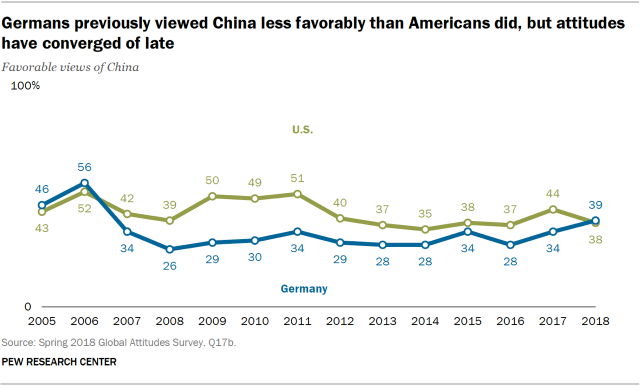

In [9]:
# ── ChartQA val 샘플 로드 ────────────────────────────────────
from datasets import load_dataset

# val 스플릿(약 1.9K)만 로드. 베이스라인 관찰엔 일부만 있으면 충분.
val = load_dataset('HuggingFaceM4/ChartQA', split='val')
print('val 샘플 수:', len(val))

sample = val[0]
image    = sample['image']      # PIL 이미지
question = sample['query']      # 질문 문자열
gold     = sample['label'][0]   # 정답(리스트의 첫 원소)

print('질문:', question)
print('정답:', gold)
image   # 노트북에 차트 이미지 표시

In [10]:
# ── 추론 함수 정의 (이후 교시에서도 재사용) ──────────────────
@torch.no_grad()  # 추론 단계에서는 gradient 계산을 끄면 VRAM 사용량이 줄고 속도가 빨라짐
def generate_answer(image, question: str, max_new_tokens: int = 64) -> str:
    """
    이미지 1장과 질문 문자열을 입력받아,
    모델이 생성한 최종 답변 문자열(str)을 반환.
    """

    # 1) Qwen3-VL 채팅 포맷에 맞는 멀티모달 메시지 구성
    #    - image: 차트 이미지
    #    - text : 사용자 질문
    messages = [{
        'role': 'user',
        'content': [
            {'type': 'image', 'image': image},
            {'type': 'text',  'text': question},
        ],
    }]

    # 2) 채팅 템플릿 적용 + 토큰화
    #    add_generation_prompt=True:
    #    모델 입력 끝에 "이제 assistant가 답할 차례" 신호를 붙여 생성 시작점을 명확히 함
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,              # 문자열을 토큰 ID로 변환
        add_generation_prompt=True, # 생성 프롬프트 추가
        return_dict=True,           # dict 형태로 반환
        return_tensors='pt',        # PyTorch tensor로 반환
    ).to(model.device)              # 모델이 올라간 디바이스(GPU)로 이동

    # 3) 생성 실행
    #    do_sample=False: 샘플링 비활성화(결정적 출력) → 같은 입력이면 같은 답 유지 next를 greedy방식(확률이 높은)
    out_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,  # 새로 생성할 최대 토큰 수
        do_sample=False
    )

    # 4) 입력 프롬프트 길이 이후 "새로 생성된 부분"만 잘라냄
    gen_ids = out_ids[0][inputs['input_ids'].shape[1]:]

    # 5) 토큰 ID를 사람이 읽을 수 있는 텍스트로 디코딩
    text = processor.decode(gen_ids, skip_special_tokens=True)

    # 앞뒤 공백 제거 후 반환
    return text.strip()


# ── 베이스라인 추론 실행 ─────────────────────────────────────
pred = generate_answer(image, question)

# 질문 / 정답 / 모델 출력 비교
print('질문 :', question)
print('정답 :', gold)
print('모델 :', pred)

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


질문 : What's the color of graph with 56 as the highest value?
정답 : Blue
모델 : The graph with the highest value of **56** is the **blue line**, which represents **Germany**.

In the chart:
- The **blue line** (Germany) starts at **46** in 2005, peaks at **56** in 2006, then declines


blue 정답을 맞추었지만 너무 장황 
- 해결 : 파인튜닝  : 형식 튜닝(Json)

In [11]:
# ── 베이스라인을 여러 샘플로 관찰 ────────────────────────────
# 학습 전 모델이 ChartQA에서 어떻게 답하는지 5개만 빠르게 살펴봄.
for i in range(5):
    s = val[i]
    pred = generate_answer(s['image'], s['query'])
    print(f"[{i}] Q: {s['query']}")
    print(f"    정답: {s['label'][0]!r}  |  모델: {pred!r}")
    print('-' * 70)

[0] Q: What's the color of graph with 56 as the highest value?
    정답: 'Blue'  |  모델: 'The graph with the highest value of **56** is the **blue line**, which represents **Germany**.\n\nIn the chart:\n- The **blue line** (Germany) starts at **46** in 2005, peaks at **56** in 2006, then declines'
----------------------------------------------------------------------
[1] Q: In which year the difference between blue and green graph 1?
    정답: '2018'  |  모델: 'Looking at the chart, we need to find the year where the difference between the blue line (Germany) and the green line (U.S.) is exactly 1.\n\nLet’s examine the values year by year:\n\n- **2005**: Germany = 46, U.S. = 43 →'
----------------------------------------------------------------------
[2] Q: What does the blue line represent?
    정답: 'Not too much/not at all'  |  모델: 'The blue line represents the percentage of respondents who believe that the U.S. takes “Not too much / not at all” into account when making international policy 

**결과 읽기 — 학습 *전* 모델의 두 가지 특징**

베이스라인 출력에서 두 가지가 뚜렷합니다.

1. **장황함**: 정답이 `'Blue'` 한 단어인데 모델은 *"The graph with the highest value of 56 is the blue line, which represents Germany…"* 처럼 **문단으로**(마크다운까지) 답합니다. 내용은 맞아도 **형식이 ChartQA의 짧은 정답과 다릅니다.**
2. **스케일/형식 불일치**: `[3]`에서 정답은 `'0.72'` 인데 모델은 `'72'` 라고 답했습니다. 차트의 72(%)를 읽었지만 **라벨의 소수 표기(0.72)와 어긋납니다.** 이런 답은 5교시 **Relaxed Accuracy로도 오답**입니다(|72 − 0.72| ÷ 0.72 가 매우 큼).

또 `[1]`처럼 *추론 과정*을 길게 쓰다 `max_new_tokens` 제한에 잘려 **정답에 도달하지 못한** 경우도 보입니다.

> **핵심**: 베이스 모델은 차트를 *이해는* 하지만 **짧고 정해진 형식으로 답하지 못합니다.** 4교시 QLoRA 학습이 가르치는 것이 바로 이 *형식·간결성*이고, 5교시에서 **같은 Relaxed Accuracy로 학습 전/후를 직접 비교**합니다. 지금 출력의 장황함과 `72 vs 0.72`를 기억해 두세요 — 학습 후 어떻게 달라지는지 대조하게 됩니다.

## 5. 정리 + 다음 교시 예고

- `BitsAndBytesConfig(nf4)` 로 **4B를 4bit로 T4에 올렸고**, VRAM이 1교시 계산(~2GB대)과 맞는지 확인했습니다.
- ChartQA에서 **학습 전 베이스라인**을 관찰했습니다. 답이 정답과 어긋나거나 군더더기가 붙는 경우를 기억해 두세요 — 4교시 학습 후와 직접 비교합니다.

### 다음 교시 — Day1-3 · ChartQA 전처리
채팅 템플릿을 학습용으로 가공하고, **프롬프트 토큰을 -100으로 마스킹**해 *답변 토큰만* 손실에 반영하는 **collate_fn**을 만듭니다. T4 보호를 위한 **이미지 해상도 상한**도 설정합니다.

> ✅ **체크포인트**: ① 4bit 로드 4필드를 설명할 수 있다 ② 측정 VRAM이 1교시 계산과 대략 일치한다 ③ 학습 전 베이스라인 출력을 직접 봤다.